# ABS SEIFA 2021 Postal Area curation

This notebook summarises the saved outputs from the reproducible SEIFA pipeline. The source is the Australian Bureau of Statistics **Postal Area, Indexes, SEIFA 2021** workbook. SEIFA describes areas rather than individual people or merchants.

Four indexes are retained: IRSD, IRSAD, IER and IEO. For most analysis, ABS recommends ranks or quantiles rather than treating raw scores as quantities.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path(r'C:\\Users\\十五\\OneDrive\\Desktop\\ads project 2\\external_seifa\\results')
clean = pd.read_parquet(RESULTS / 'seifa_clean.parquet')
coverage = pd.read_csv(RESULTS / 'consumer_join_coverage.csv')
distribution = pd.read_csv(RESULTS / 'score_distribution.csv')
quality = pd.read_csv(RESULTS / 'feature_quality_profile.csv')
metadata = json.loads((RESULTS / 'seifa_metadata.json').read_text(encoding='utf-8'))

print(f"Clean dimension: {len(clean):,} POAs x {len(clean.columns)} columns")
print(f"All four scores: {metadata['all_four_scores_rows']:,}")
print(f"Partial scores: {metadata['partial_score_rows']:,}")
print(f"No scores: {metadata['no_score_rows']:,}")

Clean dimension: 2,641 POAs x 59 columns
All four scores: 2,624
Partial scores: 3
No scores: 14


## Consumer postcode coverage

In [2]:
consumer_coverage = coverage.query("scope == 'consumer_rows'").copy()
consumer_coverage[['metric', 'rows', 'denominator', 'rate']]

,metric,rows,denominator,rate
0,matched_all_scores,414125,499999,0.828252
1,matched_partial_scores,472,499999,0.000944
2,matched_no_scores,2221,499999,0.004442
3,postcode_not_in_seifa,83181,499999,0.166362
4,special_geography,0,499999,0.000000
5,missing_or_invalid_postcode,0,499999,0.000000


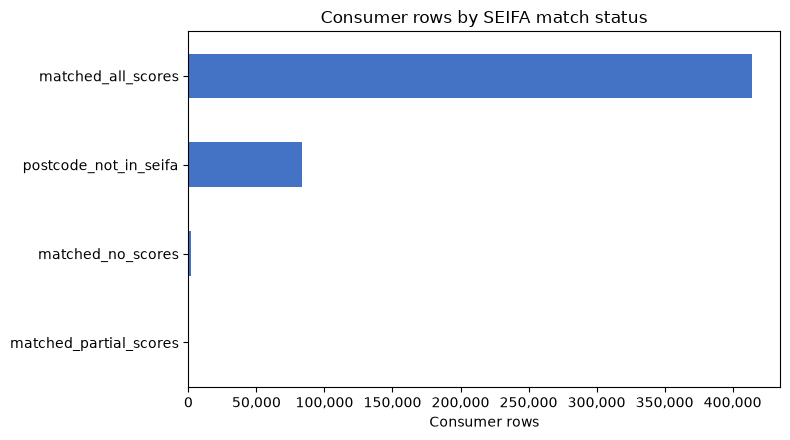

In [3]:
plot_data = consumer_coverage[consumer_coverage['rows'] > 0].sort_values('rows')
ax = plot_data.plot.barh(x='metric', y='rows', legend=False, color='#4472C4', figsize=(8, 4.5))
ax.set_title('Consumer rows by SEIFA match status')
ax.set_xlabel('Consumer rows')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:,.0f}')
plt.tight_layout()
plt.show()

## National percentile distributions

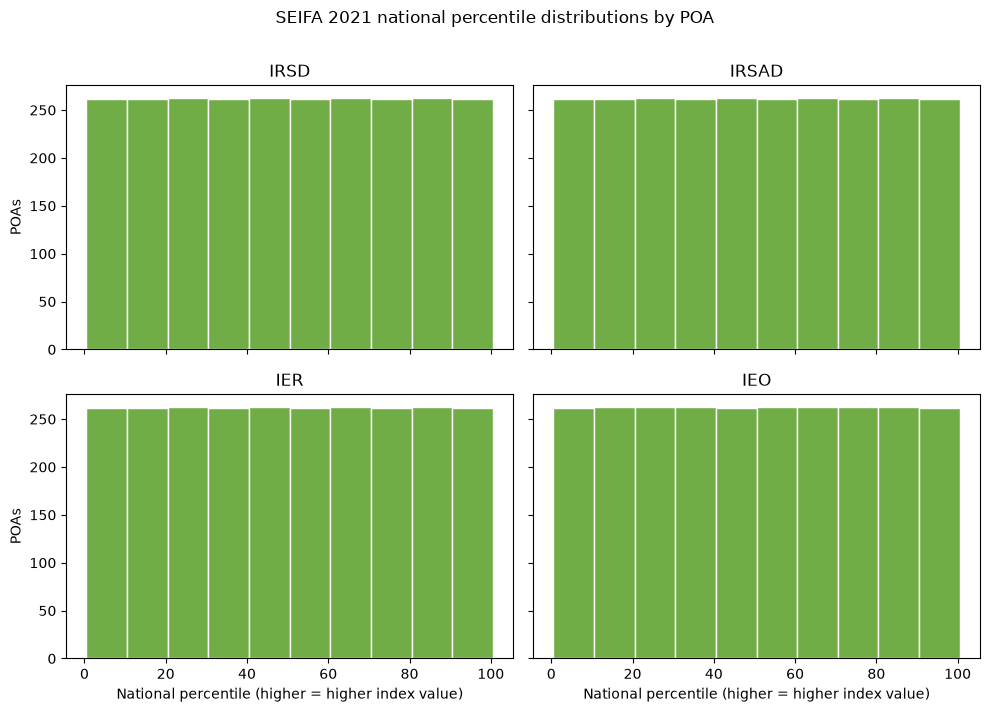

In [4]:
percentile_columns = {
    'IRSD': 'seifa_irsd_national_percentile',
    'IRSAD': 'seifa_irsad_national_percentile',
    'IER': 'seifa_ier_national_percentile',
    'IEO': 'seifa_ieo_national_percentile',
}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, (label, column) in zip(axes.ravel(), percentile_columns.items()):
    clean[column].dropna().plot.hist(bins=10, range=(0.5, 100.5), ax=ax, color='#70AD47', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('National percentile (higher = higher index value)')
    ax.set_ylabel('POAs')
fig.suptitle('SEIFA 2021 national percentile distributions by POA', y=1.01)
plt.tight_layout()
plt.show()

## Score availability and official caution flags

In [5]:
summary = pd.Series({
    'ordinary_POAs': len(clean),
    'all_four_scores': int(clean['seifa_all_scores_available'].sum()),
    'partial_scores': int((clean['seifa_any_score_available'] & ~clean['seifa_all_scores_available']).sum()),
    'no_scores': int((~clean['seifa_any_score_available']).sum()),
    'ABS_caution_flag': int(clean['seifa_caution_low_sa1_representation'].fillna(False).sum()),
    'cross_state_boundary': int(clean['seifa_cross_state_boundary'].fillna(False).sum()),
}, name='rows')
summary.to_frame()

,rows
ordinary_POAs,2641
all_four_scores,2624
partial_scores,3
no_scores,14
ABS_caution_flag,167
cross_state_boundary,15


## Interpretation and use

- Join the dimension to consumers or curated transactions using a normalised four-character postcode.
- Keep unmatched rows and use the explicit match-status field; do not replace a missing score with zero.
- Low scores, deciles and percentiles indicate relatively greater disadvantage. They do **not** measure an individual's income, education or creditworthiness.
- The four indexes overlap conceptually. Do not average all four into a merchant score without a documented model and validation, because that can double-count related information.
- SEIFA 2021 is a cross-sectional area measure. It is not a 2020–2021 economic trend and should not be used as though it were time-series GDP.